<a href="https://colab.research.google.com/github/Murtuzasaifee/multi-model-rag/blob/master/mineru_multimodal_rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multimodal RAG with MinerU: Layout-Aware Academic PDF Parsing

MinerU is a state-of-the-art PDF parsing library optimized for academic and technical documents. Unlike naive text extraction, MinerU understands:
- **Multi-column layouts** (arXiv papers, journals)
- **Mathematical equations** (LaTeX extraction)
- **Figures and tables** (with bounding boxes)
- **Reading order** (handles complex layouts)

## Pipeline Overview
```
PDF → [MinerU Layout Analysis] → content_list.json
                                         ↓
                            ┌────────────┴────────────┐
                            ↓            ↓             ↓
                         Text         Figures       Tables
                         Chunks       (GPT-4o       (pandas
                           ↓          caption)       → MD)
                           └────────────┴─────────────┘
                                        ↓
                              text-embedding-3-small
                                        ↓
                              Zilliz Cloud / Qdrant
                                        ↓
                                  GPT-4o RAG
```

## Prerequisites
- Python 3.12+
- CUDA GPU (8GB+ VRAM) recommended for full multimodal parsing
- CPU fallback: set `BACKEND = "pipeline"` and `PARSE_METHOD = "txt"` for fast, text-only extraction (no figures/equations)
- OpenAI API key
- Zilliz Cloud URI + Token (or local Qdrant)
- MinerU model weights (~3.4 GB for pipeline backend, downloaded on first run)

## 1. Installation

In [ ]:
import subprocess
import sys

# For CLI users: uv pip install -r requirements-parsing.txt
# Notebook install via pip for venv compatibility:
packages = [
    "mineru[all]",
    "openai>=2.24.0",
    "langchain>=1.2.12",
    "langchain-openai>=1.1.10",
    "pymilvus>=2.4.0",
    "qdrant-client>=1.17.0",
    "python-dotenv>=1.0.0",
    "ragas>=0.4.3",
    "datasets>=2.21.0",
    "Pillow>=11.0.0",
    "tenacity>=9.0.0",
    "tiktoken>=0.9.0",
    "rich>=14.0.0",
    "tqdm>=4.67.0",
    "pandas>=2.2.0",
]

subprocess.run(
    [sys.executable, "-m", "pip", "install"] + packages,
    check=True,
    capture_output=True,
    text=True,
)
print("✓ All packages installed")

## 2. GPU / CUDA Validation

In [ ]:
import torch
from rich.table import Table
from rich.console import Console

console = Console()

# BACKEND selects the mineru processing engine.
# PARSE_METHOD controls page-type detection (orthogonal to backend).
BACKEND = "hybrid-auto-engine"   # GPU default
PARSE_METHOD = "auto"

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    cuda_version = torch.version.cuda

    if vram_gb < 8.0:
        BACKEND = "pipeline"
        console.print(f"[yellow]⚠ GPU has {vram_gb:.1f}GB VRAM (<8GB). Using backend='pipeline'.[/yellow]")

    table = Table(title="GPU Info", show_header=True)
    table.add_column("Property", style="cyan")
    table.add_column("Value", style="green")
    table.add_row("GPU Name", gpu_name)
    table.add_row("VRAM (GB)", f"{vram_gb:.1f}")
    table.add_row("CUDA Version", cuda_version)
    table.add_row("Backend", BACKEND)
    table.add_row("Parse Method", PARSE_METHOD)
    console.print(table)
else:
    BACKEND = "pipeline"    # CPU-only backend — no GPU required
    console.print(
        "[yellow]⚠ No GPU detected. Using backend='pipeline' (CPU-only).\n"
        "Math equations and figures will not be extracted at full accuracy.[/yellow]"
    )

print(f"\nBACKEND = '{BACKEND}'")
print(f"PARSE_METHOD = '{PARSE_METHOD}'")

              GPU Info               
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Property     ┃ Value              ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ GPU Name     │ NVIDIA L4          │
│ VRAM (GB)    │ 23.7               │
│ CUDA Version │ 12.8               │
│ Backend      │ hybrid-auto-engine │
│ Parse Method │ auto               │
└──────────────┴────────────────────┘


BACKEND = 'hybrid-auto-engine'
PARSE_METHOD = 'auto'


## 3. Environment Setup

In [ ]:
import os
import logging
from pathlib import Path
from dotenv import load_dotenv

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
ZILLIZ_URI = os.getenv("ZILLIZ_URI")
ZILLIZ_TOKEN = os.getenv("ZILLIZ_TOKEN")
QDRANT_URL = os.getenv("QDRANT_URL", "http://localhost:6333")

# Validate required keys
missing = []
if not OPENAI_API_KEY:
    missing.append("OPENAI_API_KEY")
if not ZILLIZ_URI and not QDRANT_URL:
    missing.append("ZILLIZ_URI or QDRANT_URL")

if missing:
    logger.warning("Missing env vars: %s — check your .env file", ", ".join(missing))
else:
    logger.info("✓ OPENAI_API_KEY loaded")
    logger.info("✓ Vector store config loaded (Zilliz=%s)", bool(ZILLIZ_URI))

USE_ZILLIZ = bool(ZILLIZ_URI and ZILLIZ_TOKEN)
print(f"Vector store: {'Zilliz Cloud' if USE_ZILLIZ else 'Qdrant (local)'}")

INFO: ✓ OPENAI_API_KEY loaded
INFO: ✓ Vector store config loaded (Zilliz=True)


Vector store: Zilliz Cloud


In [ ]:
import os

OUTPUT_DIR = Path("mineru_output")
DIRS = [
    OUTPUT_DIR,
    OUTPUT_DIR / "figures",
    OUTPUT_DIR / "tables",
    OUTPUT_DIR / "chunks",
    Path("docs"),
]

for d in DIRS:
    d.mkdir(parents=True, exist_ok=True)

print("Output directories created:")
for d in DIRS:
    print(f"  {d}/")

Output directories created:
  mineru_output/
  mineru_output/figures/
  mineru_output/tables/
  mineru_output/chunks/
  docs/


In [ ]:
import subprocess

# Pre-fetch MinerU model weights.
# pipeline backend: ~3.4 GB. hybrid/vlm backends: additional VLM weights (~8 GB total).
# Models auto-download on first parse if this cell is skipped.
if BACKEND != "pipeline":
    try:
        result = subprocess.run(
            ["mineru-models-download"],
            check=True,
            capture_output=True,
            text=True,
            timeout=600,
        )
        print("✓ MinerU model weights ready")
        if result.stdout:
            print(result.stdout[-500:])
    except FileNotFoundError:
        logger.warning("mineru-models-download not found. Models will auto-download on first parse.")
        print("⚠ CLI not found — models will download on first run")
    except subprocess.CalledProcessError as e:
        logger.warning("Model prefetch failed: %s — falling back to pipeline backend", e)
        BACKEND = "pipeline"
        print("⚠ Prefetch failed. Falling back to BACKEND='pipeline'")
    except subprocess.TimeoutExpired:
        logger.warning("Model download timed out — will retry on first parse")
        print("⚠ Download timed out — models will attempt on first parse")
else:
    print(f"Backend='{BACKEND}': pipeline models auto-download on first parse. Skipping prefetch.")

print(f"\nFinal BACKEND = '{BACKEND}'")

⚠ Prefetch failed. Falling back to BACKEND='pipeline'

Final BACKEND = 'pipeline'


## 4. Backend & Parse Mode Selection

MinerU has two orthogonal settings:

**`BACKEND`** — controls the *processing engine* (set automatically by GPU detection in Cell 2):

| Backend | GPU Required | Notes |
|---|---|---|
| `pipeline` | No (CPU-only) | Fast, conservative; ~3.4 GB models |
| `hybrid-auto-engine` | Yes (8GB+ VRAM) | Best accuracy; layout + VLM |
| `vlm-auto-engine` | Yes (10GB+ VRAM) | Highest accuracy, slower |
| `vlm-http-client` | No | Delegates to a remote VLM server |

**`PARSE_METHOD`** — controls *page-type detection* (orthogonal to backend):

| Parse Method | Document Type | GPU Needed? |
|---|---|---|
| `auto` | Mixed — auto-detects native text vs scanned per page | Recommended |
| `txt` | Native text PDF only (fast, no OCR) | No |
| `ocr` | Fully scanned document | Yes |

> **`BACKEND` and `PARSE_METHOD` are independent.** You can use `backend="pipeline"` with `parse_method="auto"` for CPU inference, or `backend="hybrid-auto-engine"` with `parse_method="txt"` if you want the hybrid engine but text-only extraction.

In [ ]:
BACKEND

'hybrid-auto-engine'

In [ ]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Literal

VALID_BACKENDS = frozenset({
    "pipeline", "vlm-transformers", "vlm-vllm-engine",
    "vlm-mlx-engine", "vlm-http-client",
    "hybrid-auto-engine", "hybrid-http-client",
})

@dataclass
class MinerUConfig:
    # mineru engine selection
    backend: str = "pipeline"
    # page-type detection (orthogonal to backend)
    parse_method: Literal["auto", "txt", "ocr"] = "auto"
    # output
    output_dir: Path = field(default_factory=lambda: Path("mineru_output"))
    # chunking
    chunk_size: int = 512
    chunk_overlap: int = 50
    max_pages_per_batch_cpu: int = 20
    max_pages_per_batch_gpu: int = 50
    # generation
    vlm_model: str = "gpt-4o"
    vlm_max_tokens: int = 256
    # embedding
    embedding_model: str = "text-embedding-3-small"
    embedding_dimensions: int = 1536
    # vector store
    collection_name: str = "mineru_academic_rag"
    use_zilliz: bool = False

    def __post_init__(self) -> None:
        if self.backend not in VALID_BACKENDS:
            raise ValueError(f"Invalid backend '{self.backend}'. Valid: {sorted(VALID_BACKENDS)}")

cfg = MinerUConfig(
    backend=BACKEND,
    parse_method=PARSE_METHOD,
    use_zilliz=USE_ZILLIZ,
)
print(f"Config: backend={cfg.backend}, parse_method={cfg.parse_method}")
print(f"        embedding={cfg.embedding_model}")
print(f"        collection={cfg.collection_name}, zilliz={cfg.use_zilliz}")

Config: backend=hybrid-auto-engine, parse_method=auto
        embedding=text-embedding-3-small
        collection=mineru_academic_rag, zilliz=True


In [ ]:
import json
from mineru.cli.common import do_parse


def run_mineru_parse(pdf_path: Path, cfg: MinerUConfig) -> Path:
    """
    Run mineru do_parse() on a single PDF. Returns the backend output directory.

    MinerU actual output structure:
        {cfg.output_dir}/{pdf_filename}/{backend_slug}/
            {pdf_filename}.md
            {pdf_filename}_content_list.json
            {pdf_filename}_middle.json
            images/

    Note: MinerU uses the full pdf filename (with .pdf) as both the subdir name
    and the output file prefix. The backend_slug is derived from cfg.backend
    (e.g. "hybrid-auto-engine" → "hybrid_auto"). We use glob to avoid hard-coding
    the slug transformation.
    """
    pdf_bytes = pdf_path.read_bytes()

    do_parse(
        output_dir=str(cfg.output_dir),
        pdf_file_names=[pdf_path.name],
        pdf_bytes_list=[pdf_bytes],
        p_lang_list=["en"],
        backend=cfg.backend,
        parse_method=cfg.parse_method,
        formula_enable=True,
        table_enable=True,
        f_dump_md=True,
        f_dump_middle_json=True,
        f_dump_content_list=True,   # REQUIRED — enables content_list.json output
    )

    # MinerU creates: {output_dir}/{pdf_filename}/{backend_slug}/
    # Use glob to locate the content_list.json regardless of backend slug name.
    matches = [
        p for p in cfg.output_dir.rglob(f"{pdf_path.name}_content_list.json")
        if "_v2" not in p.name
    ]
    if not matches:
        raise FileNotFoundError(
            f"do_parse() produced no content_list.json under {cfg.output_dir}. "
            f"Check the MinerU logs above for errors."
        )
    # Return the backend subdir (parent of the json file) — contains images/ too
    return matches[0].parent

## ⚠ MinerU Gotchas

**Internet required on first run (`auto` mode):**
MinerU downloads layout detection and OCR model weights (~3.4 GB) from Hugging Face on first use. Ensure network access or pre-download with `mineru-models-download`.

**Multi-column reading order:**
MinerU sometimes interleaves columns incorrectly on 2-column arXiv papers. The `check_reading_order()` helper below detects this. Workaround: split multi-column PDFs before parsing, or use `parse_method="txt"` for structure-only extraction.

**Math equation quality:**
LaTeX equations from `auto` mode are syntactically correct but may have recognition errors. Always generate a plain-English GPT-4o description alongside the raw LaTeX for better embedding recall.

**Figure minimum size:**
Filter out figures smaller than 100×100px — these are typically logos, decorative elements, or rendering artifacts.

## 5. Download Sample Documents

We use two arXiv papers that showcase MinerU's strengths:
1. **"Attention is All You Need"** (1706.03762) — multi-column layout, tables with BLEU scores
2. **DDPM** (2006.11239) — math-heavy, complex figures

In [ ]:
import urllib.request
import time

PAPERS = {
    "attention_is_all_you_need": "https://arxiv.org/pdf/1706.03762",
    "ddpm": "https://arxiv.org/pdf/2006.11239",
}

DOC_DIR = Path("docs")
downloaded = {}

for name, url in PAPERS.items():
    dest = DOC_DIR / f"{name}.pdf"
    if dest.exists():
        print(f"✓ {dest} already exists ({dest.stat().st_size / 1e6:.1f} MB)")
        downloaded[name] = dest
    else:
        print(f"Downloading {name}...")
        try:
            urllib.request.urlretrieve(url, dest)
            print(f"✓ {dest} ({dest.stat().st_size / 1e6:.1f} MB)")
            downloaded[name] = dest
            time.sleep(1)  # be polite to arXiv
        except Exception as e:
            print(f"✗ Failed to download {name}: {e}")
            print("  Manually download from:", url)

DEMO_PDF = downloaded.get("attention_is_all_you_need", DOC_DIR / "attention_is_all_you_need.pdf")
print(f"\nDemo PDF: {DEMO_PDF}")

✓ docs/attention_is_all_you_need.pdf (2.2 MB)
✓ docs/ddpm.pdf (10.3 MB)

Demo PDF: docs/attention_is_all_you_need.pdf


## 6. Single Document Parsing Demo

Parse the Attention paper to understand MinerU's output structure.

In [ ]:
import time
import json


def parse_document(pdf_path: Path, cfg: MinerUConfig) -> tuple[list[dict], Path]:
    """
    Parse a single PDF with mineru. Returns (content_list, doc_output_dir).

    doc_output_dir is the backend subdir returned by run_mineru_parse():
        {cfg.output_dir}/{pdf_filename}/{backend_slug}/

    content_list schema: list of dicts with keys:
        type (str): "text" | "title" | "image" | "table" | "equation" | "interline_equation"
        text (str): text content (text/title elements)
        table_body (str): HTML table string (table elements)
        img_path (str): relative image path (image elements)
        latex (str): LaTeX source (equation elements)
        page_idx (int): 0-based page number
    """
    t0 = time.time()

    # run_mineru_parse returns the backend subdir containing all outputs
    doc_output_dir = run_mineru_parse(pdf_path, cfg)

    # MinerU names outputs as {pdf_filename}_content_list.json
    # e.g. attention_is_all_you_need.pdf_content_list.json  (NOT stem_content_list.json)
    content_list_path = doc_output_dir / f"{pdf_path.name}_content_list.json"
    if not content_list_path.exists():
        raise FileNotFoundError(
            f"content_list.json not found at {content_list_path}. "
            f"do_parse() may have failed. Check {doc_output_dir} for partial outputs."
        )

    with content_list_path.open("r", encoding="utf-8") as fh:
        content_list = json.load(fh)

    if not isinstance(content_list, list):
        raise ValueError(
            f"Expected list in {content_list_path}, got {type(content_list).__name__}"
        )

    elapsed = time.time() - t0
    print(f"✓ Parsed {pdf_path.name}: {len(content_list)} elements in {elapsed:.1f}s")
    return content_list, doc_output_dir


demo_content_list, demo_output_dir = parse_document(DEMO_PDF, cfg)

2026-03-20 08:06:36.698 | INFO     | mineru.utils.engine_utils:get_vlm_engine:32 - Using vllm-engine as the inference engine for VLM.
INFO: generated new fontManager


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/teamspace/studios/this_studio/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

2026-03-20 08:06:43.462 | INFO     | mineru.backend.vlm.utils:enable_custom_logits_processors:55 - compute_capability: 8.9 >= 8.0 and vllm version: 0.11.0 >= 0.10.1, enable custom_logits_processors


INFO 03-20 08:06:44 [__init__.py:216] Automatically detected platform cuda.
INFO 03-20 08:06:49 [utils.py:233] non-default args: {'gpu_memory_utilization': 0.5, 'disable_log_stats': True, 'logits_processors': [<class 'mineru_vl_utils.logits_processor.vllm_v1_no_repeat_ngram.VllmV1NoRepeatNGramLogitsProcessor'>], 'model': '/teamspace/studios/this_studio/.cache/huggingface/hub/models--opendatalab--MinerU2.5-2509-1.2B/snapshots/879e58bdd9566632b27a8a81f0e2961873311f67'}
INFO 03-20 08:07:07 [model.py:547] Resolved architecture: Qwen2VLForConditionalGeneration


...

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

MFD Predict: 100%|█| 15/15 
MFR Predict: 100%|█| 80/80 
OCR-det: 100%|█| 15/15 [00:
2026-03-20 08:09:21.501 | DEBUG    | mineru.backend.hybrid.hybrid_analyze:doc_analyze:437 - infer finished, cost: 45.68, speed: 0.328 page/s
2026-03-20 08:09:21.958 | DEBUG    | mineru.utils.magic_model_utils:tie_up_category_by_index:269 - Obj index: 2, Sub index: 1, Edge distance: 120.50311199301038
2026-03-20 08:09:21.959 | DEBUG    | mineru.utils.magic_model_utils:tie_up_category_by_index:269 - Obj index: 2, Sub index: 3, Edge distance: 2
2026-03-20 08:09:21.960 | DEBUG    | mineru.utils.magic_model_utils:tie_up_category_by_index:274 - Obj index: 2, edge_dist_diff > 2, matching to subject with min edge distance, index: 3
2026-03-20 08:09:25.292 | INFO     | mineru.cli.common:_process_output:168 - local output dir is mineru_output/attention_is_all_you_need.pdf/hybrid_auto


✓ Parsed attention_is_all_you_need.pdf: 159 elements in 173.8s


In [ ]:
from rich.tree import Tree
from rich import print as rprint

def build_file_tree(directory: Path, tree: Tree = None) -> Tree:
    if tree is None:
        tree = Tree(f"[bold]{directory}/[/bold]")
    for path in sorted(directory.iterdir()):
        if path.is_dir():
            branch = tree.add(f"[cyan]{path.name}/[/cyan]")
            build_file_tree(path, branch)
        else:
            size_kb = path.stat().st_size / 1024
            tree.add(f"{path.name} ({size_kb:.1f} KB)")
    return tree

rprint(build_file_tree(demo_output_dir))

mineru_output/attention_is_all_you_need.pdf/hybrid_auto/
├── attention_is_all_you_need.pdf.md (42.0 KB)
├── attention_is_all_you_need.pdf_content_list.json (73.9 KB)
├── attention_is_all_you_need.pdf_content_list_v2.json (139.9 KB)
├── attention_is_all_you_need.pdf_layout.pdf (3328.7 KB)
├── attention_is_all_you_need.pdf_middle.json (630.1 KB)
├── attention_is_all_you_need.pdf_model.json (93.6 KB)
├── attention_is_all_you_need.pdf_origin.pdf (3151.2 KB)
└── images/
    ├── 008d5ae889b32373bc314fabc09e38cc65cace6e71e55f870bcd4f762632a453.jpg (8.3 KB)
    ├── 15f147b860ad8b4693886a3fd8ba2cba1755f871cef6fe8e772281b5f0c180a4.jpg (4.6 KB)
    ├── 24e3898f39f8c5cd97b756d2bf00fb84dca521a239567f0c01e34e017d2b6dd3.jpg (4.8 KB)
    ├── 522289bb889e18ba9d80ac3acaf9af923b7ef1c0cd5466e6eb6c40308f5245d2.jpg (7.3 KB)
    ├── 56290d9a2b14958c7799ce44e5317291632444e9a20a500b30ae7a04a020b0a2.jpg (20.0 KB)
    ├── 59552b139c619ad9d9c604f552cae64624e9f8bafe4b4b7283650c7007b1acc3.jpg (6.7 KB)
    ├── 5f0519f587dfa1718c4bb9aeb8f44e1307c30bd07d803bf6ef7aee5b5b386a5a.jpg (109.5 KB)
    ├── 86d6b2671f1a6da0908e6afc0c1874d6aaa1a928f41467f1c3b682ab6ec6e4d2.jpg (5.1 KB)
    ├── 88cd2510dfa1298329d38bc4b12b4a9bf255189722089f1b862158963ec184a8.jpg (85.5 KB)
    ├── 9be8d51258cd6fe2526d8800d553f7108651a1d4c49433a59883f07396f92286.jpg (49.5 KB)
    ├── a8fdf50822fc846c184d3dd5ce6a5a7f4511781921204befa5f3e415ae3df09c.jpg (6.7 KB)
    ├── ab55762a03c90d3932909aa4ef32179d5d0f8a56250249870c4369fe4b0b1d56.jpg (68.9 KB)
    ├── bd63cd8ef663420b999bad3a3aae91811bd7280633013dfcf7da5b6af166555e.jpg (37.4 KB)
    ├── be12fe5cdac40d7bba8036ae5bdc9c7f235860dfab1966e90dcd633db77b3244.jpg (11.9 KB)
    ├── d018247de7540bbbd7d638e7b3a9aa21d04567cb8492ac4ce39dc5526098c0b6.jpg (66.8 KB)
    ├── d417a63d9d480919dfe427682f3cd8cd08a1cfce8623736fbf76a84de208b8b8.jpg (73.2 KB)
    ├── dd29c4dbc9b873b082c9f751cc974e6254bc431b82d886c0dde12e3cf70f1901.jpg (73.5 KB)
    └── e3fb9cad957f9b4bf3ca0f51f12310d12ce648d3b8229acf2b011bd17d6dce25.jpg (90.2 KB)

In [ ]:
import json
import pandas as pd
from collections import Counter

# Count element types
type_counts = Counter(elem.get("type", "unknown") for elem in demo_content_list)

# Display as DataFrame
df_types = pd.DataFrame(
    [(t, c) for t, c in sorted(type_counts.items(), key=lambda x: -x[1])],
    columns=["element_type", "count"],
)
print("Element type distribution:")
print(df_types.to_string(index=False))

# ── DEBUG: Inspect actual table element fields ──────────────────────────────
table_elems = [e for e in demo_content_list if e.get("type") == "table"]
print(f"\n--- Table elements found: {len(table_elems)} ---")
if table_elems:
    e0 = table_elems[0]
    print(f"Keys present:  {list(e0.keys())}")
    print(f"table_body:    {repr(e0.get('table_body', ''))[:300]}")
    print(f"html:          {repr(e0.get('html', ''))[:300]}")
    print(f"text:          {repr(e0.get('text', ''))[:300]}")
else:
    # If 0 table elements, show ALL unique types to find the real type name
    print("No 'table' type found. All types present:")
    for t, c in sorted(type_counts.items(), key=lambda x: -x[1]):
        print(f"  {t!r}: {c} elements")
    # Show any non-standard element as a sample
    print("\nSample of unusual elements (non text/title/image/equation):")
    for elem in demo_content_list:
        t = elem.get("type", "unknown")
        if t not in ("text", "title", "image", "equation", "interline_equation"):
            print(f"  type={t!r}  keys={list(elem.keys())}")
            print(f"  preview: {str(elem)[:200]}")
            print()
            break

# ── Also check if content_list_v2.json has more data ───────────────────────
v2_paths = list(demo_output_dir.glob("*_content_list_v2.json"))
if v2_paths:
    print(f"\n--- content_list_v2.json found: {v2_paths[0].name} ---")
    with v2_paths[0].open() as f:
        v2_data = json.load(f)
    flat = [e for sublist in v2_data for e in sublist]
    v2_types = Counter(e.get("type", "unknown") for e in flat)
    print(f"v2 element count: {len(flat)}")
    for t, c in sorted(v2_types.items(), key=lambda x: -x[1]):
        print(f"  {t}: {c}")
    v2_tables = [e for e in flat if e.get("type") == "table"]
    if v2_tables:
        print(f"\nv2 table element keys: {list(v2_tables[0].keys())}")
        print(f"v2 table_body sample:  {repr(v2_tables[0].get('table_body',''))[:300]}")
else:
    print("\nNo content_list_v2.json found.")

# ── Sample one element of each type ────────────────────────────────────────
print("\n--- Sample elements (one per type) ---")
seen_types = set()
for elem in demo_content_list:
    t = elem.get("type", "unknown")
    if t not in seen_types:
        seen_types.add(t)
        print(f"\n[{t}]  keys={list(elem.keys())}")
        print(f"  page: {elem.get('page_idx', '?')}")
        print(f"  text: {str(elem.get('text', ''))[:150]}")


Element type distribution:
 element_type  count
         text    115
  page_number     14
        image      7
     equation      7
page_footnote      5
         list      4
        table      4
       header      1
       footer      1
   aside_text      1

--- Table elements found: 4 ---
Keys present:  ['type', 'img_path', 'table_caption', 'table_footnote', 'table_body', 'bbox', 'page_idx']
table_body:    '<table><tr><td>Layer Type</td><td>Complexity per Layer</td><td>Sequential Operations</td><td>Maximum Path Length</td></tr><tr><td>Self-Attention</td><td>O(n2·d)</td><td>O(1)</td><td>O(1)</td></tr><tr><td>Recurrent</td><td>O(n·d2)</td><td>O(n)</td><td>O(n)</td></tr><tr><td>Convolutional</td><td>O(k·
html:          ''
text:          ''

--- content_list_v2.json found: attention_is_all_you_need.pdf_content_list_v2.json ---
v2 element count: 159
  paragraph: 89
  title: 26
  page_number: 14
  image: 7
  equation_interline: 7
  page_footnote: 5
  list: 4
  table: 4
  page_header: 1
  pa

In [ ]:
def check_reading_order(content_list: list[dict]) -> list[int]:
    """
    Detect potential multi-column reading order bugs.

    MinerU sometimes interleaves columns on 2-column layouts.
    Returns page indices where y-coordinate inversions are detected.
    """
    from collections import defaultdict
    pages = defaultdict(list)

    for elem in content_list:
        page = elem.get("page_idx", 0)
        bbox = elem.get("bbox")
        if bbox and len(bbox) >= 4:
            y_top = bbox[1]
            pages[page].append(y_top)

    flagged_pages = []
    for page_num, y_coords in sorted(pages.items()):
        inversions = sum(
            1 for i in range(len(y_coords) - 1)
            if y_coords[i] > y_coords[i + 1] + 50  # 50px threshold
        )
        if inversions > 3:  # more than 3 inversions suggests column interleaving
            flagged_pages.append(page_num)

    if flagged_pages:
        print(f"⚠ Potential reading order issues on pages: {flagged_pages}")
        print("  Tip: These pages may have multi-column layouts with interleaved text.")
    else:
        print("✓ No significant reading order issues detected")

    return flagged_pages

flagged = check_reading_order(demo_content_list)

✓ No significant reading order issues detected


In [ ]:
from IPython.display import Markdown, display

# Load and display a preview of the MinerU markdown output
md_files = list(demo_output_dir.glob("*.md"))
if md_files:
    md_content = md_files[0].read_text(encoding="utf-8")
    # Show first 3000 chars to avoid overwhelming the notebook
    display(Markdown(md_content[:3000] + "\n\n*[... truncated for display ...]*"))
else:
    print("No markdown file found — check output directory")

# Attention Is All You Need

Ashish Vaswani∗

Google Brain

avaswani@google.com

Noam Shazeer∗

Google Brain

noam@google.com

Niki Parmar∗

Google Research

nikip@google.com

Jakob Uszkoreit∗

Google Research

usz@google.com

Llion Jones∗

Google Research

llion@google.com

Aidan N. Gomez∗ †

University of Toronto

aidan@cs.toronto.edu

Łukasz Kaiser∗

Google Brain

lukaszkaiser@google.com

Illia Polosukhin∗ ‡

illia.polosukhin@gmail.com

# Abstract

The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring significantly less time to train. Our model achieves 28.4 BLEU on the WMT 2014 Englishto-German translation task, improving over the existing best results, including ensembles, by over 2 BLEU. On the WMT 2014 English-to-French translation task, our model establishes a new single-model state-of-the-art BLEU score of 41.8 after training for 3.5 days on eight GPUs, a small fraction of the training costs of the best models from the literature. We show that the Transformer generalizes well to other tasks by applying it successfully to English constituency parsing both with large and limited training data.

# 1 Introduction

Recurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks in particular, have been firmly established as state of the art approaches in sequence modeling and transduction problems such as language modeling and machine translation [35, 2, 5]. Numerous efforts have since continued to push the boundaries of recurrent language models and encoder-decoder architectures [38, 24, 15].

Recurrent models typically factor computation along the symbol positions of the input and output sequences. Aligning the positions to steps in computation time, they generate a sequence of hidden states $h _ { t }$ , as a function of the previous hidden state $h _ { t - 1 }$ and the input for position $t$ . This inherently sequential nature precludes parallelization within training examples, which becomes critical at longer sequence lengths, as memory constraints limit batching across examples. Recent work has achieved significant improvements in computational efficiency through factorization tricks [21] and conditional computation [32], while also improving model performance in case of the latter. The fundamental constraint of sequential computation, however, remains.

Attention mechanisms have become an integral part of compelling sequence modeling and transduction models in various tasks, allowing modeling of dependencies without regard to their dista

*[... truncated for display ...]*

## 7. Batch Document Parsing

Parse multiple PDFs, handling errors gracefully so one failure doesn't stop the batch.

In [ ]:
from tqdm import tqdm

def parse_document_batch(
    pdf_paths: list[Path], cfg: MinerUConfig
) -> tuple[dict[str, list[dict]], dict[str, Path]]:
    """
    Parse a batch of PDFs. Continues on per-document errors.

    Returns:
        results:     dict mapping doc_id (stem) → content_list
        output_dirs: dict mapping doc_id (stem) → backend output dir (contains images/)
    """
    results = {}
    output_dirs = {}
    summary_rows = []

    for pdf_path in tqdm(pdf_paths, desc="Parsing PDFs"):
        doc_id = pdf_path.stem
        t0 = time.time()
        try:
            content_list, doc_output_dir = parse_document(pdf_path, cfg)
            type_counts = Counter(e.get("type", "unknown") for e in content_list)
            elapsed = time.time() - t0

            results[doc_id] = content_list
            output_dirs[doc_id] = doc_output_dir
            summary_rows.append({
                "doc_id": doc_id,
                "elements": len(content_list),
                "text": type_counts.get("text", 0),
                "title": type_counts.get("title", 0),
                "figure": type_counts.get("image", 0),
                "table": type_counts.get("table", 0),
                "equation": type_counts.get("equation", 0),
                "elapsed_s": round(elapsed, 1),
                "status": "ok",
            })
        except Exception as e:
            logger.error("Failed to parse %s: %s", pdf_path.name, e)
            summary_rows.append({
                "doc_id": doc_id,
                "elements": 0,
                "text": 0,
                "title": 0,
                "figure": 0,
                "table": 0,
                "equation": 0,
                "elapsed_s": round(time.time() - t0, 1),
                "status": f"error: {e}",
            })

    df = pd.DataFrame(summary_rows)
    print("\nBatch parsing summary:")
    print(df.to_string(index=False))
    return results, output_dirs


# Run batch on all downloaded PDFs
all_content_lists, all_output_dirs = parse_document_batch(list(downloaded.values()), cfg)

Parsing PDFs:   0%| | 0/2 [2026-03-20 08:21:58.902 | INFO     | mineru.utils.engine_utils:get_vlm_engine:32 - Using vllm-engine as the inference engine for VLM.
2026-03-20 08:21:58.910 | DEBUG    | mineru.utils.pdf_image_tools:load_images_from_pdf:116 - PDF to images using 4 processes, page ranges: [(0, 2), (3, 5), (6, 8), (9, 14)]
2026-03-20 08:22:00.160 | DEBUG    | mineru.backend.hybrid.hybrid_analyze:doc_analyze:405 - load images cost: 1.26, speed: 11.905 images/s
2026-03-20 08:22:03.220 | INFO     | mineru.backend.hybrid.hybrid_analyze:get_batch_ratio:365 - hybrid batch ratio (auto, vram=22GB): 8


Adding requests:   0%|          | 0/15 [00:00<?, ?it/s]

Processed prompts:   0%| | 

Adding requests:   0%|          | 0/12 [00:00<?, ?it/s]

Processed prompts:   0%| | 

...

Processed prompts:   0%| | 

Adding requests:   0%|          | 0/33 [00:00<?, ?it/s]

Processed prompts:   0%| | 

MFD Predict: 100%|█| 25/25 
MFR Predict: 100%|█| 193/19
OCR-det: 100%|█| 25/25 [00:
2026-03-20 08:23:02.706 | DEBUG    | mineru.backend.hybrid.hybrid_analyze:doc_analyze:437 - infer finished, cost: 33.8, speed: 0.74 page/s
2026-03-20 08:23:03.482 | DEBUG    | mineru.utils.magic_model_utils:tie_up_category_by_index:269 - Obj index: 1, Sub index: 0, Edge distance: 4
2026-03-20 08:23:03.483 | DEBUG    | mineru.utils.magic_model_utils:tie_up_category_by_index:269 - Obj index: 1, Sub index: 2, Edge distance: 18.439088914585774
2026-03-20 08:23:03.484 | DEBUG    | mineru.utils.magic_model_utils:tie_up_category_by_index:274 - Obj index: 1, edge_dist_diff > 2, matching to subject with min edge distance, index: 0
2026-03-20 08:23:03.610 | DEBUG    | mineru.utils.magic_model_utils:tie_up_category_by_index:269 - Obj index: 9, Sub index: 8, Edge distance: 6
2026-03-20 08:23:03.611 | DEBUG    | mineru.utils.magic_model_utils:tie_up_category_by_index:269 - Obj index: 9, Sub index: 10, Edge distance:

✓ Parsed ddpm.pdf: 182 elements in 43.1s

Batch parsing summary:
                   doc_id  elements  text  title  figure  table  equation  elapsed_s status
attention_is_all_you_need       155   111      0       7      4         7       24.7     ok
                     ddpm       182    97      0      29      5        19       43.1     ok


In [ ]:
all_elements = []
for doc_id, content_list in all_content_lists.items():
    for elem in content_list:
        elem_copy = dict(elem)
        elem_copy["doc_id"] = doc_id
        all_elements.append(elem_copy)

print(f"Total elements across all documents: {len(all_elements)}")
type_dist = Counter(e.get("type", "unknown") for e in all_elements)
for t, c in sorted(type_dist.items(), key=lambda x: -x[1]):
    print(f"  {t}: {c}")

Total elements across all documents: 337
  text: 208
  page_number: 38
  image: 36
  equation: 26
  list: 11
  table: 9
  page_footnote: 5
  aside_text: 2
  header: 1
  footer: 1


## 8. Content Decomposition for RAG

Each element type requires a different handling strategy:

| Element Type | MinerU Key | RAG Strategy |
|---|---|---|
| `text` | `text` | Chunk with RecursiveCharacterTextSplitter |
| `title` | `text` | Preserve as section_header metadata |
| `image` | `img_path` | GPT-4o caption → text chunk |
| `table` | `table_body` (fallback: `html`) | pandas → Markdown **+ GPT-4o plain-text summary** |
| `equation` / `interline_equation` | `latex` (fallback: `text`) | Store raw LaTeX + GPT-4o plain-English desc |

> **Why caption figures?** Raw image paths don't embed well. GPT-4o captions create rich, searchable text representations of visual content.

> **Why describe equations AND summarise tables?** Both have the same embedding problem:
> - LaTeX `\frac{\partial^2 u}{\partial t^2}` is semantically distant from "wave equation"
> - A Markdown table `| Transformer (base model) | 27.3 |` is semantically distant from "BLEU score of the Transformer base model on WMT 2014"
>
> In both cases, a GPT-4o-generated plain-English representation bridges the gap. Each table chunk stores `[Table Summary]: ...` followed by `[Table Data]: ...` (the Markdown), so both semantic search and exact data are available to the LLM.

In [ ]:
from dataclasses import dataclass

@dataclass
class RagChunk:
    text: str
    doc_id: str
    page_number: int
    element_type: str   # text | title | figure | table | equation
    modality: str       # text | image
    source_path: str
    chunk_index: int
    image_path: str | None = None
    section_header: str | None = None

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
import tiktoken

def chunk_text_elements(
    elements: list[dict],
    cfg: MinerUConfig,
    doc_id: str,
    source_path: str,
) -> list[RagChunk]:
    """Chunk text and title elements into RagChunks."""
    enc = tiktoken.encoding_for_model("text-embedding-3-small")
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=cfg.chunk_size,
        chunk_overlap=cfg.chunk_overlap,
        length_function=lambda t: len(enc.encode(t)),
        separators=["\n\n", "\n", ". ", " ", ""],
    )

    chunks = []
    chunk_idx = 0
    current_section = None

    for elem in elements:
        etype = elem.get("type", "")
        text = elem.get("text", "").strip()
        page = elem.get("page_idx", 0)

        if not text:
            continue

        if etype == "title":
            current_section = text
            # Titles are short — store as single chunk
            chunks.append(RagChunk(
                text=text,
                doc_id=doc_id,
                page_number=page,
                element_type="title",
                modality="text",
                source_path=source_path,
                chunk_index=chunk_idx,
                section_header=current_section,
            ))
            chunk_idx += 1

        elif etype == "text":
            sub_chunks = splitter.split_text(text)
            for sc in sub_chunks:
                chunks.append(RagChunk(
                    text=sc,
                    doc_id=doc_id,
                    page_number=page,
                    element_type="text",
                    modality="text",
                    source_path=source_path,
                    chunk_index=chunk_idx,
                    section_header=current_section,
                ))
                chunk_idx += 1

    return chunks


# Test on demo document
text_elements = [e for e in all_elements if e.get("type") in ("text", "title")]
demo_text_chunks = chunk_text_elements(
    [e for e in text_elements if e.get("doc_id") == "attention_is_all_you_need"],
    cfg,
    "attention_is_all_you_need",
    str(DEMO_PDF),
)
print(f"Text chunks from attention paper: {len(demo_text_chunks)}")
print(f"\nExample chunk:")
print(f"  text: {demo_text_chunks[0].text[:200]}")
print(f"  section: {demo_text_chunks[0].section_header}")

Text chunks from attention paper: 111

Example chunk:
  text: Attention Is All You Need
  section: None


In [ ]:
import base64
import asyncio
from openai import AsyncOpenAI
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
from openai import RateLimitError, APITimeoutError
from PIL import Image

openai_client = AsyncOpenAI(api_key=OPENAI_API_KEY)

def is_figure_valid(image_path: Path, min_size: int = 100) -> bool:
    """Filter out small logos/decorations."""
    try:
        with Image.open(image_path) as img:
            w, h = img.size
            return w >= min_size and h >= min_size
    except Exception:
        return False


@retry(
    retry=retry_if_exception_type((RateLimitError, APITimeoutError)),
    wait=wait_exponential(multiplier=1, min=2, max=60),
    stop=stop_after_attempt(5),
)
async def caption_figure(image_path: Path, client: AsyncOpenAI, cfg: MinerUConfig) -> str:
    """Generate a RAG-optimized caption for a figure using GPT-4o vision."""
    with open(image_path, "rb") as f:
        img_data = base64.b64encode(f.read()).decode("utf-8")

    suffix = image_path.suffix.lower()
    mime = "image/png" if suffix == ".png" else "image/jpeg"

    response = await client.chat.completions.create(
        model=cfg.vlm_model,
        messages=[{
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:{mime};base64,{img_data}"},
                },
                {
                    "type": "text",
                    "text": (
                        "You are a RAG caption generator. Describe this figure in 2-4 sentences "
                        "for retrieval purposes. Include: what is shown, key values/labels, "
                        "and what concept it illustrates. Be specific and factual."
                    ),
                },
            ],
        }],
        max_tokens=cfg.vlm_max_tokens,
    )
    return response.choices[0].message.content.strip()


async def process_figures(
    elements: list[dict],
    cfg: MinerUConfig,
    doc_id: str,
    source_path: str,
    doc_output_dir: Path,
    start_idx: int = 0,
) -> list[RagChunk]:
    """Process all figures in a document, generating GPT-4o captions."""
    figure_elements = [e for e in elements if e.get("type") == "image"]
    chunks = []
    chunk_idx = start_idx

    for elem in tqdm(figure_elements, desc=f"Captioning figures ({doc_id})"):
        img_path_str = elem.get("img_path") or elem.get("image_path", "")
        if not img_path_str:
            continue

        img_path = doc_output_dir / "images" / Path(img_path_str).name
        if not img_path.exists():
            img_path = Path(img_path_str)
        if not img_path.exists():
            continue

        if not is_figure_valid(img_path):
            logger.debug("Skipping small figure: %s", img_path.name)
            continue

        try:
            caption = await caption_figure(img_path, openai_client, cfg)
        except Exception as e:
            logger.warning("Figure captioning failed for %s: %s", img_path.name, e)
            caption = f"[Figure: {img_path.name}]"

        chunks.append(RagChunk(
            text=caption,
            doc_id=doc_id,
            page_number=elem.get("page_idx", 0),
            element_type="figure",
            modality="image",
            source_path=source_path,
            chunk_index=chunk_idx,
            image_path=str(img_path),
        ))
        chunk_idx += 1

    return chunks

## 8a. Figure Captioning Preview

Inspect the first 5 extracted figures from the demo document.
For each image we show: the raw figure → GPT-4o caption → the exact chunk text
that will be embedded and stored in the vector database.

Total figure elements in 'attention_is_all_you_need': 7
Previewing first 5...



──────── Figure 1 of 5  |  page 2  |  d018247de7540bbbd7d638e7b3a9aa21d04567cb8492ac4ce39dc5526098c0b6.jpg ────────

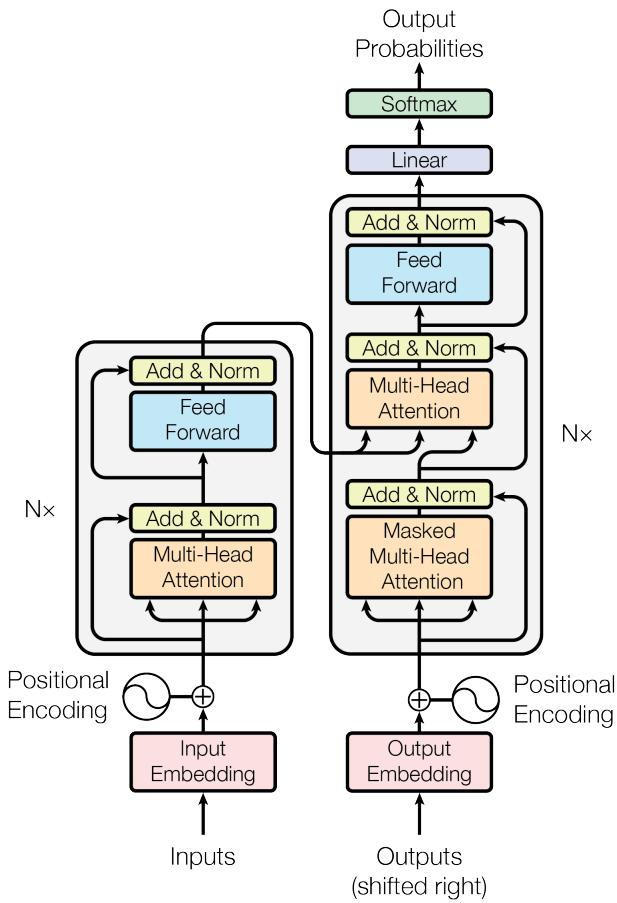

Generating GPT-4o caption...

INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


╭──────────────────────────────────────────────── GPT-4o Caption ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  This diagram illustrates the architecture of a Transformer model, highlighting the encoder-decoder structure.  │
│  The left side shows the encoder, consisting of multiple layers (N times) of "Add & Norm," "Multi-Head          │
│  Attention," and "Feed Forward" sub-layers. The right side depicts the decoder, also with stacked layers,       │
│  incorporating "Masked Multi-Head Attention" to prevent future token information leakage. Positional Encoding   │
│  is added to the input/output embeddings to incorporate sequence order, and the final linear and softmax        │
│  layers produce output probabilities.                                                                           │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Final RagChunk ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  element_type: figure                                                                                           │
│  modality:     image                                                                                            │
│  doc_id:       attention_is_all_you_need                                                                        │
│  page_number:  2                                                                                                │
│  image_path:   d018247de7540bbbd7d638e7b3a9aa21d04567cb8492ac4ce39dc5526098c0b6.jpg                             │
│                                                                                                                 │
│  text (embedded → VectorDB):                                                                                    │
│  This diagram illustrates the architecture of a Transformer model, highlighting the encoder-decoder structure.  │
│  The left side shows the encoder, consisting of multiple layers (N times) of "Add & Norm," "Multi-Head          │
│  Attention," and "Feed Forward" sub-layers. The right side depicts the decoder, also with stacked layers,       │
│  incorporating "Masked Multi-Head Attention" to prevent future token information leakage. Positional Encoding   │
│  is added to the input/output embeddings to incorporate sequence order, and the final linear and softmax        │
│  layers produce output probabilities.                                                                           │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

──────── Figure 2 of 5  |  page 3  |  f6dceb511da7122ed2f01f877ef9a8a8c01a11927c6116181cc64816561b0ed4.jpg ────────

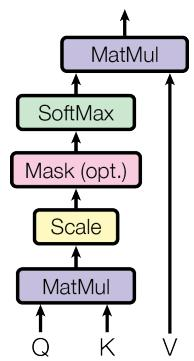

Generating GPT-4o caption...

INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


╭──────────────────────────────────────────────── GPT-4o Caption ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  The figure illustrates the scaled dot-product attention mechanism in transformer models. It shows the          │
│  sequential operations performed on the query (Q), key (K), and value (V) matrices. The process begins with a   │
│  matrix multiplication of Q and K, followed by optional masking. The result is then scaled and passed through   │
│  a softmax function before another matrix multiplication with V. This flow demonstrates the attention           │
│  calculation in neural network architectures.                                                                   │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Final RagChunk ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  element_type: figure                                                                                           │
│  modality:     image                                                                                            │
│  doc_id:       attention_is_all_you_need                                                                        │
│  page_number:  3                                                                                                │
│  image_path:   f6dceb511da7122ed2f01f877ef9a8a8c01a11927c6116181cc64816561b0ed4.jpg                             │
│                                                                                                                 │
│  text (embedded → VectorDB):                                                                                    │
│  The figure illustrates the scaled dot-product attention mechanism in transformer models. It shows the          │
│  sequential operations performed on the query (Q), key (K), and value (V) matrices. The process begins with a   │
│  matrix multiplication of Q and K, followed by optional masking. The result is then scaled and passed through   │
│  a softmax function before another matrix multiplication with V. This flow demonstrates the attention           │
│  calculation in neural network architectures.                                                                   │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

──────── Figure 3 of 5  |  page 3  |  56290d9a2b14958c7799ce44e5317291632444e9a20a500b30ae7a04a020b0a2.jpg ────────

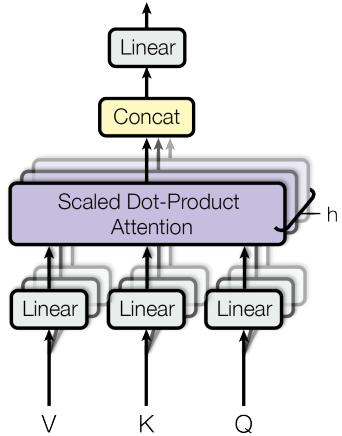

Generating GPT-4o caption...

INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


╭──────────────────────────────────────────────── GPT-4o Caption ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  This figure illustrates the architecture of the Multi-Head Attention mechanism used in transformer models. It  │
│  depicts the process where input vectors are linearly transformed into queries (Q), keys (K), and values (V),   │
│  which then undergo the Scaled Dot-Product Attention process. Multiple attention heads, denoted by "h", are     │
│  processed in parallel, and their outputs are concatenated. Finally, a linear transformation is applied to the  │
│  concatenated result, showcasing the sequence of operations involved in multi-head attention.                   │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Final RagChunk ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  element_type: figure                                                                                           │
│  modality:     image                                                                                            │
│  doc_id:       attention_is_all_you_need                                                                        │
│  page_number:  3                                                                                                │
│  image_path:   56290d9a2b14958c7799ce44e5317291632444e9a20a500b30ae7a04a020b0a2.jpg                             │
│                                                                                                                 │
│  text (embedded → VectorDB):                                                                                    │
│  This figure illustrates the architecture of the Multi-Head Attention mechanism used in transformer models. It  │
│  depicts the process where input vectors are linearly transformed into queries (Q), keys (K), and values (V),   │
│  which then undergo the Scaled Dot-Product Attention process. Multiple attention heads, denoted by "h", are     │
│  processed in parallel, and their outputs are concatenated. Finally, a linear transformation is applied to the  │
│  concatenated result, showcasing the sequence of operations involved in multi-head attention.                   │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

─────── Figure 4 of 5  |  page 12  |  f27694de4a0822dc61a37335e6148024b8610949bc4bb20b76a3868c9072a66b.jpg ────────

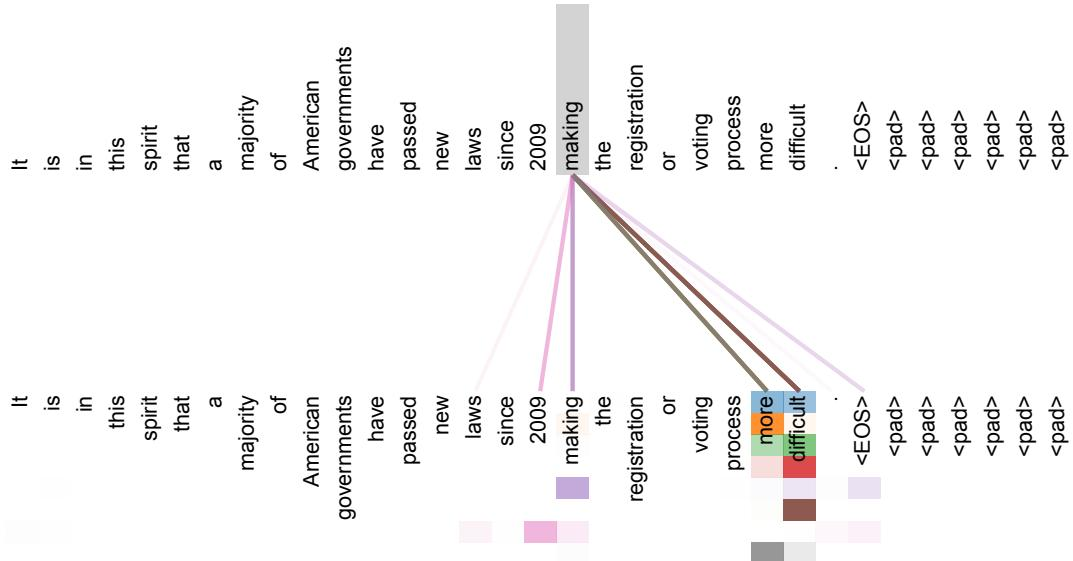

Generating GPT-4o caption...

INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


╭──────────────────────────────────────────────── GPT-4o Caption ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  The figure is an attention map from a transformer model, illustrating the association between input and        │
│  output tokens in a sentence. The input sentence is "It is in this spirit that a majority of American           │
│  governments have passed new laws since 2009 making the registration or voting process more difficult." The     │
│  attention lines, varying in color intensity, show connections between the word "making" in the input and the   │
│  words "more difficult" in the output. It highlights how the model focuses attention on specific parts of the   │
│  input when generating the output, capturing the relationship between sentence structure and meaning.           │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Final RagChunk ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  element_type: figure                                                                                           │
│  modality:     image                                                                                            │
│  doc_id:       attention_is_all_you_need                                                                        │
│  page_number:  12                                                                                               │
│  image_path:   f27694de4a0822dc61a37335e6148024b8610949bc4bb20b76a3868c9072a66b.jpg                             │
│                                                                                                                 │
│  text (embedded → VectorDB):                                                                                    │
│  The figure is an attention map from a transformer model, illustrating the association between input and        │
│  output tokens in a sentence. The input sentence is "It is in this spirit that a majority of American           │
│  governments have passed new laws since 2009 making the registration or voting process more difficult." The     │
│  attention lines, varying in color intensity, show connections between the word "making" in the input and the   │
│  words "more difficult" in the output. It highlights how the model focuses attention on specific parts of the   │
│  input when generating the output, capturing the relationship between sentence structure and meaning.           │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

─────── Figure 5 of 5  |  page 13  |  5f0519f587dfa1718c4bb9aeb8f44e1307c30bd07d803bf6ef7aee5b5b386a5a.jpg ────────

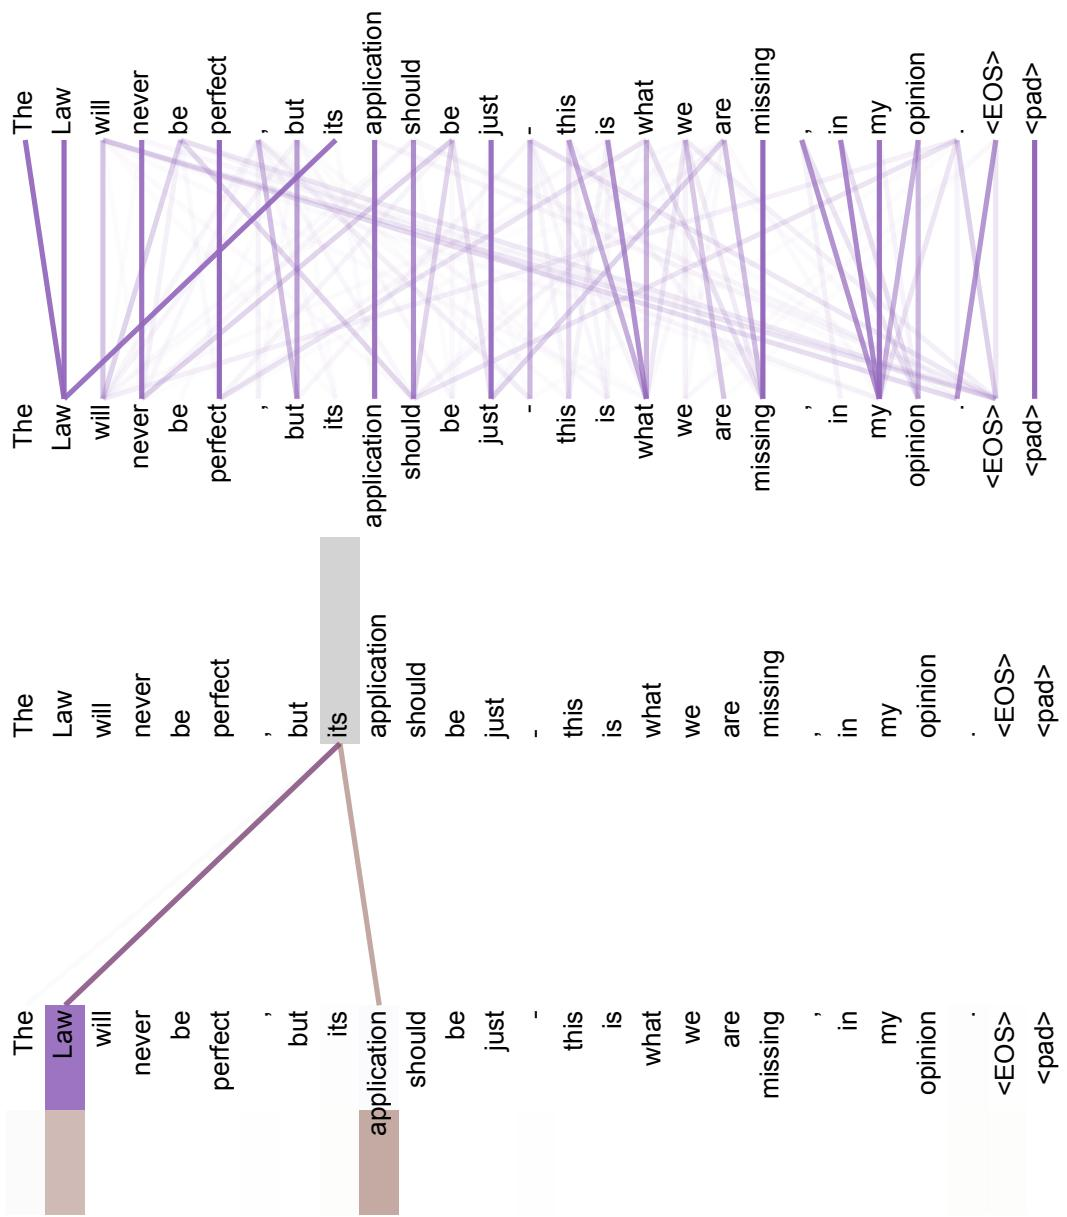

Generating GPT-4o caption...

INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


╭──────────────────────────────────────────────── GPT-4o Caption ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  This figure shows an attention visualization for a Transformer model, illustrating how different words in a    │
│  sentence relate to each other during processing. The input sequence includes: "The Law will never be perfect,  │
│  but its application should be just. This is what we are missing, in my opinion." The attention lines connect   │
│  words that are attended to by the model, with varying thickness indicating the strength of attention. Key      │
│  tokens in the sequence include "Law," "application," and "<EOS>." This visualization helps in understanding    │
│  how Transformer models distribute attention across words during tasks like translation or summarization.       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Final RagChunk ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  element_type: figure                                                                                           │
│  modality:     image                                                                                            │
│  doc_id:       attention_is_all_you_need                                                                        │
│  page_number:  13                                                                                               │
│  image_path:   5f0519f587dfa1718c4bb9aeb8f44e1307c30bd07d803bf6ef7aee5b5b386a5a.jpg                             │
│                                                                                                                 │
│  text (embedded → VectorDB):                                                                                    │
│  This figure shows an attention visualization for a Transformer model, illustrating how different words in a    │
│  sentence relate to each other during processing. The input sequence includes: "The Law will never be perfect,  │
│  but its application should be just. This is what we are missing, in my opinion." The attention lines connect   │
│  words that are attended to by the model, with varying thickness indicating the strength of attention. Key      │
│  tokens in the sequence include "Law," "application," and "<EOS>." This visualization helps in understanding    │
│  how Transformer models distribute attention across words during tasks like translation or summarization.       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

───────────────────────────────────────────────────── Summary ─────────────────────────────────────────────────────

 figure  page                                       image                                                                                                             caption_preview
      1     2 d018247de7540bbbd7d638e7b3a9aa21d04567cb... This diagram illustrates the architecture of a Transformer model, highlighting the encoder-decoder structure. The left s...
      2     3 f6dceb511da7122ed2f01f877ef9a8a8c01a1192... The figure illustrates the scaled dot-product attention mechanism in transformer models. It shows the sequential operati...
      3     3 56290d9a2b14958c7799ce44e5317291632444e9... This figure illustrates the architecture of the Multi-Head Attention mechanism used in transformer models. It depicts th...
      4    12 f27694de4a0822dc61a37335e6148024b8610949... The figure is an attention map from a transformer model, illustrating the association between input and output tokens in...
      5    13 5f0519f587dfa1718c4bb9aeb8f44e1307c30bd0... This figure shows an attention v

In [ ]:
from IPython.display import display, Image as IPImage
from rich.console import Console
from rich.panel import Panel
from rich.columns import Columns
from rich.text import Text

console = Console()

# ── Config ───────────────────────────────────────────────────────────────────
MAX_FIGURES = 5      # how many figures to preview
DOC_ID      = "attention_is_all_you_need"

# ── Collect figure elements from the demo document ───────────────────────────
figure_elements = [
    e for e in all_elements
    if e.get("doc_id") == DOC_ID and e.get("type") == "image"
]
print(f"Total figure elements in '{DOC_ID}': {len(figure_elements)}")
print(f"Previewing first {min(MAX_FIGURES, len(figure_elements))}...\n")

preview_chunks = []

for i, elem in enumerate(figure_elements[:MAX_FIGURES]):
    img_path_str = elem.get("img_path") or elem.get("image_path", "")
    page          = elem.get("page_idx", "?")

    # Resolve image path
    img_path = demo_output_dir / "images" / Path(img_path_str).name
    if not img_path.exists():
        img_path = Path(img_path_str)
    if not img_path.exists():
        console.print(f"[red]Figure {i+1}: image file not found — {img_path_str}[/red]")
        continue

    if not is_figure_valid(img_path):
        console.print(f"[yellow]Figure {i+1}: too small (<100px), skipped[/yellow]")
        continue

    # ── Show the image inline ─────────────────────────────────────────────────
    console.rule(f"[bold cyan]Figure {i+1} of {MAX_FIGURES}  |  page {page}  |  {img_path.name}[/bold cyan]")
    display(IPImage(filename=str(img_path), width=480))

    # ── Generate caption ──────────────────────────────────────────────────────
    console.print("[dim]Generating GPT-4o caption...[/dim]")
    try:
        caption = await caption_figure(img_path, openai_client, cfg)
    except Exception as e:
        caption = f"[Caption failed: {e}]"

    # ── The final chunk text (exactly what gets embedded & stored) ────────────
    # process_figures() stores the caption directly as the chunk text
    chunk_text = caption

    # ── Display caption + chunk ───────────────────────────────────────────────
    console.print(Panel(
        caption,
        title="[green]GPT-4o Caption[/green]",
        border_style="green",
        padding=(1, 2),
    ))
    console.print(Panel(
        f"[bold]element_type:[/bold] figure\n"
        f"[bold]modality:[/bold]     image\n"
        f"[bold]doc_id:[/bold]       {DOC_ID}\n"
        f"[bold]page_number:[/bold]  {page}\n"
        f"[bold]image_path:[/bold]   {img_path.name}\n\n"
        f"[bold]text (embedded → VectorDB):[/bold]\n{chunk_text}",
        title="[magenta]Final RagChunk[/magenta]",
        border_style="magenta",
        padding=(1, 2),
    ))

    # Collect for summary table
    preview_chunks.append({
        "figure": i + 1,
        "page": page,
        "image": img_path.name[:40] + "..." if len(img_path.name) > 40 else img_path.name,
        "caption_preview": caption[:120] + "..." if len(caption) > 120 else caption,
    })
    print()

# ── Summary table ─────────────────────────────────────────────────────────────
if preview_chunks:
    console.rule("[bold]Summary[/bold]")
    df_preview = pd.DataFrame(preview_chunks)
    print(df_preview.to_string(index=False))
    print(f"\n✓ {len(preview_chunks)} figure chunks ready for embedding.")

In [ ]:
import re
from io import StringIO


async def extract_table_via_vision(
    img_path: Path, client: AsyncOpenAI, cfg: MinerUConfig
) -> str:
    """
    Use GPT-4o vision to extract and summarise a table rendered as an image.

    MinerU's hybrid/VLM backends often save tables as cropped images rather than
    HTML when structured extraction fails. This recovers the content via vision.
    """
    if not img_path.exists():
        return ""
    with open(img_path, "rb") as f:
        img_b64 = base64.b64encode(f.read()).decode()
    suffix = img_path.suffix.lower()
    mime = "image/png" if suffix == ".png" else "image/jpeg"

    response = await client.chat.completions.create(
        model=cfg.vlm_model,
        messages=[{
            "role": "user",
            "content": [
                {"type": "image_url",
                 "image_url": {"url": f"data:{mime};base64,{img_b64}"}},
                {"type": "text", "text": (
                    "This image shows a table from an academic paper. "
                    "First, reproduce every row and column value in plain text (e.g. "
                    "'Model X achieves 27.3 BLEU on EN-DE'). "
                    "Then write 3-5 sentences summarising the key findings. "
                    "Be specific: include model names, metric names, and numeric values."
                )},
            ],
        }],
        max_tokens=500,
        temperature=0.0,
    )
    return response.choices[0].message.content.strip()


async def summarize_table(md_table: str, client: AsyncOpenAI, cfg: MinerUConfig) -> str:
    """Generate a plain-text summary of a Markdown table for semantic retrieval."""
    response = await client.chat.completions.create(
        model=cfg.vlm_model,
        messages=[{
            "role": "user",
            "content": (
                "You are a RAG indexing assistant. Summarize the key facts in this table "
                "as 3-6 plain-English sentences, mentioning specific values, model names, "
                "and metric names so the table is searchable by natural-language queries.\n\n"
                f"Table:\n{md_table}"
            ),
        }],
        max_tokens=300,
        temperature=0.0,
    )
    return response.choices[0].message.content.strip()


async def process_tables(
    elements: list[dict],
    cfg: MinerUConfig,
    doc_id: str,
    source_path: str,
    doc_output_dir: Path,
    start_idx: int = 0,
) -> list[RagChunk]:
    """
    Convert tables to searchable RAG chunks using two strategies:

    Strategy A — HTML available (pipeline backend):
        table_body/html → pandas Markdown → GPT-4o plain-text summary

    Strategy B — HTML empty (hybrid/VLM backend renders tables as images):
        img_path → GPT-4o vision → extracts all values + summary in one call

    Both strategies store semantically rich text so the embedding is close to
    natural-language queries like "BLEU score of Transformer base model".
    """
    table_elements = [e for e in elements if e.get("type") == "table"]
    chunks = []
    chunk_idx = start_idx

    logger.info("Processing %d table elements for %s", len(table_elements), doc_id)

    for elem in tqdm(table_elements, desc=f"Processing tables ({doc_id})"):
        html = elem.get("table_body", "") or elem.get("html", "")
        raw_text = elem.get("text", "")
        img_path_str = elem.get("img_path", "") or elem.get("image_path", "")
        page = elem.get("page_idx", 0)

        combined_text = ""

        # ── Strategy A: HTML/text extraction ────────────────────────────────
        md_table = ""
        if html:
            try:
                dfs = pd.read_html(StringIO(html))
                if dfs:
                    md_table = dfs[0].to_markdown(index=False)
            except Exception:
                pass

        chunk_text = md_table if md_table else raw_text

        if chunk_text.strip():
            try:
                summary = await summarize_table(chunk_text, openai_client, cfg)
                combined_text = f"[Table Summary]: {summary}\n\n[Table Data]:\n{chunk_text}"
            except Exception as e:
                logger.warning("Table summary failed (page %d): %s", page, e)
                combined_text = chunk_text

        # ── Strategy B: Vision fallback (hybrid/VLM backend) ────────────────
        elif img_path_str:
            # Resolve image path relative to doc_output_dir/images/
            img_path = doc_output_dir / "images" / Path(img_path_str).name
            if not img_path.exists():
                img_path = Path(img_path_str)

            if img_path.exists():
                logger.info("Table on page %d has no HTML — using vision extraction", page)
                try:
                    combined_text = await extract_table_via_vision(
                        img_path, openai_client, cfg
                    )
                except Exception as e:
                    logger.warning("Table vision extraction failed (page %d): %s", page, e)
            else:
                logger.warning(
                    "Table on page %d: no HTML and image not found at %s", page, img_path
                )

        if not combined_text.strip():
            logger.warning("Table on page %d has no extractable content — skipping", page)
            continue

        chunks.append(RagChunk(
            text=combined_text,
            doc_id=doc_id,
            page_number=page,
            element_type="table",
            modality="text",
            source_path=source_path,
            chunk_index=chunk_idx,
        ))
        chunk_idx += 1

    return chunks


# Test on demo document — note: now requires doc_output_dir
demo_table_chunks = await process_tables(
    [e for e in all_elements if e.get("doc_id") == "attention_is_all_you_need"],
    cfg,
    "attention_is_all_you_need",
    str(DEMO_PDF),
    doc_output_dir=demo_output_dir,
)
print(f"Table chunks: {len(demo_table_chunks)}")
if demo_table_chunks:
    print("\nFirst table chunk preview:")
    print(demo_table_chunks[0].text[:600])

INFO: Processing 4 table elements for attention_is_all_you_need
Processing tables (attentioINFO: Table on page 5 has no HTML — using vision extraction
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Processing tables (attentioINFO: Table on page 7 has no HTML — using vision extraction
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Processing tables (attentioINFO: Table on page 8 has no HTML — using vision extraction
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Processing tables (attentioINFO: Table on page 9 has no HTML — using vision extraction
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Processing tables (attentio

Table chunks: 4

First table chunk preview:
Layer Type | Complexity per Layer | Sequential Operations | Maximum Path Length  
--- | --- | --- | ---  
Self-Attention | \(O(n^2 \cdot d)\) | \(O(1)\) | \(O(1)\)  
Recurrent | \(O(n \cdot d^2)\) | \(O(n)\) | \(O(n)\)  
Convolutional | \(O(k \cdot n \cdot d^2)\) | \(O(1)\) | \(O(\log_k(n))\)  
Self-Attention (restricted) | \(O(r \cdot n \cdot d)\) | \(O(1)\) | \(O(n/r)\)  

### Summary

The table compares different neural network layer types based on their computational complexity, sequential operations, and maximum path length. Self-attention layers have a complexity of \(O(n^2 \cdot d)\) bu


In [ ]:
demo_table_chunks

[RagChunk(text='Layer Type | Complexity per Layer | Sequential Operations | Maximum Path Length  \n--- | --- | --- | ---  \nSelf-Attention | \\(O(n^2 \\cdot d)\\) | \\(O(1)\\) | \\(O(1)\\)  \nRecurrent | \\(O(n \\cdot d^2)\\) | \\(O(n)\\) | \\(O(n)\\)  \nConvolutional | \\(O(k \\cdot n \\cdot d^2)\\) | \\(O(1)\\) | \\(O(\\log_k(n))\\)  \nSelf-Attention (restricted) | \\(O(r \\cdot n \\cdot d)\\) | \\(O(1)\\) | \\(O(n/r)\\)  \n\n### Summary\n\nThe table compares different neural network layer types based on their computational complexity, sequential operations, and maximum path length. Self-attention layers have a complexity of \\(O(n^2 \\cdot d)\\) but require only \\(O(1)\\) sequential operations and have a maximum path length of \\(O(1)\\), making them efficient for parallel processing. Recurrent layers, on the other hand, have a complexity of \\(O(n \\cdot d^2)\\) and require \\(O(n)\\) sequential operations, resulting in a longer maximum path length of \\(O(n)\\). Convolutional lay

In [ ]:
async def describe_equation(latex: str, client: AsyncOpenAI, cfg: MinerUConfig) -> str:
    """Convert LaTeX equation to plain-English description for better embedding recall."""
    response = await client.chat.completions.create(
        model=cfg.vlm_model,
        messages=[{
            "role": "user",
            "content": (
                f"Describe this mathematical equation in plain English for a search index. "
                f"Explain what it computes, what each symbol means, and its purpose. "
                f"Be concise (2-3 sentences).\n\nEquation: {latex}"
            ),
        }],
        max_tokens=200,
    )
    return response.choices[0].message.content.strip()


async def process_equations(
    elements: list[dict],
    cfg: MinerUConfig,
    doc_id: str,
    source_path: str,
    start_idx: int = 0,
) -> list[RagChunk]:
    """Store equations as LaTeX + plain-English description."""
    eq_elements = [e for e in elements if e.get("type") in ("equation", "interline_equation")]
    chunks = []
    chunk_idx = start_idx

    for elem in eq_elements:
        latex = (elem.get("latex") or elem.get("text", "")).strip()
        page = elem.get("page_idx", 0)
        if not latex:
            continue

        try:
            description = await describe_equation(latex, openai_client, cfg)
        except Exception as e:
            logger.warning("Equation description failed: %s", e)
            description = f"Mathematical equation: {latex[:100]}"

        # Store both LaTeX and description for comprehensive retrieval
        combined_text = f"LaTeX: {latex}\n\nDescription: {description}"

        chunks.append(RagChunk(
            text=combined_text,
            doc_id=doc_id,
            page_number=page,
            element_type="equation",
            modality="text",
            source_path=source_path,
            chunk_index=chunk_idx,
        ))
        chunk_idx += 1

    return chunks

In [ ]:
async def decompose_all_documents(
    all_content_lists: dict[str, list[dict]],
    all_output_dirs: dict[str, Path],
    cfg: MinerUConfig,
    downloaded: dict[str, Path],
) -> list[RagChunk]:
    """Run full decomposition pipeline on all documents."""
    all_chunks = []

    for doc_id, content_list in all_content_lists.items():
        source_path = str(downloaded.get(doc_id, Path(doc_id)))
        # The backend subdir that contains images/ and all output files
        doc_output_dir = all_output_dirs.get(doc_id, cfg.output_dir)

        # Text chunks
        text_chunks = chunk_text_elements(content_list, cfg, doc_id, source_path)
        all_chunks.extend(text_chunks)
        print(f"{doc_id}: {len(text_chunks)} text chunks")

        # Figure chunks (async)
        fig_chunks = await process_figures(
            content_list, cfg, doc_id, source_path, doc_output_dir,
            start_idx=len(all_chunks),
        )
        all_chunks.extend(fig_chunks)
        print(f"{doc_id}: {len(fig_chunks)} figure chunks")

        # Table chunks (async — Strategy A: HTML→Markdown, Strategy B: vision)
        table_chunks = await process_tables(
            content_list, cfg, doc_id, source_path,
            doc_output_dir=doc_output_dir,
            start_idx=len(all_chunks),
        )
        all_chunks.extend(table_chunks)
        print(f"{doc_id}: {len(table_chunks)} table chunks")

        # Equation chunks (async)
        eq_chunks = await process_equations(
            content_list, cfg, doc_id, source_path, start_idx=len(all_chunks)
        )
        all_chunks.extend(eq_chunks)
        print(f"{doc_id}: {len(eq_chunks)} equation chunks")

    return all_chunks


all_chunks = await decompose_all_documents(
    all_content_lists, all_output_dirs, cfg, downloaded
)

# Display breakdown
df_chunks = pd.DataFrame([
    {"element_type": c.element_type, "modality": c.modality, "doc_id": c.doc_id}
    for c in all_chunks
])
print("\n=== Chunk breakdown ===")
print(df_chunks.groupby(["element_type", "modality"]).size().reset_index(name="count").to_string(index=False))
print(f"\nTotal chunks: {len(all_chunks)}")

attention_is_all_you_need: 111 text chunks


Captioning figures (attentiINFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Captioning figures (attentiINFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Captioning figures (attentiINFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Captioning figures (attentiINFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Captioning figures (attentiINFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Captioning figures (attentiINFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Captioning figures (attentiINFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Captioning figures (attenti
INFO: Processing 4 table elements for attention_is_all_you_need


attention_is_all_you_need: 7 figure chunks


Processing tables (attentioINFO: Table on page 5 has no HTML — using vision extraction
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Processing tables (attentioINFO: Table on page 7 has no HTML — using vision extraction
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Processing tables (attentioINFO: Table on page 8 has no HTML — using vision extraction
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Processing tables (attentioINFO: Table on page 9 has no HTML — using vision extraction
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Processing tables (attentio


attention_is_all_you_need: 4 table chunks


...

ddpm: 29 figure chunks


Processing tables (ddpm):  INFO: Table on page 3 has no HTML — using vision extraction
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Processing tables (ddpm):  INFO: Table on page 4 has no HTML — using vision extraction
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Processing tables (ddpm):  INFO: Table on page 5 has no HTML — using vision extraction
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Processing tables (ddpm):  INFO: Table on page 12 has no HTML — using vision extraction
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Processing tables (ddpm):  INFO: Table on page 12 has no HTML — using vision extraction
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Processing tables (ddpm): 1


ddpm: 5 table chunks


INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/cha

ddpm: 19 equation chunks

=== Chunk breakdown ===
element_type modality  count
    equation     text     26
      figure    image     36
       table     text      9
        text     text    208

Total chunks: 279


In [ ]:
eq_chunks

NameError: name 'eq_chunks' is not defined

## 9. Embedding

Using OpenAI `text-embedding-3-small` (1536-dim) for all chunk types. We estimate token count with tiktoken before sending to the API.

In [ ]:
async def embed_chunks(
    chunks: list[RagChunk],
    client: AsyncOpenAI,
    cfg: MinerUConfig,
    batch_size: int = 100,
) -> list[list[float]]:
    """
    Embed all chunks in batches of 100 (API limit awareness).

    Returns flat list of embeddings in same order as input chunks.
    """
    enc = tiktoken.encoding_for_model("text-embedding-3-small")
    texts = [c.text for c in chunks]

    # Estimate token count
    total_tokens = sum(len(enc.encode(t)) for t in texts)
    logger.info("Embedding %d chunks (~%d tokens)", len(texts), total_tokens)

    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding batches"):
        batch = texts[i : i + batch_size]
        response = await client.embeddings.create(
            model=cfg.embedding_model,
            input=batch,
            dimensions=cfg.embedding_dimensions,
        )
        batch_embeddings = [item.embedding for item in response.data]
        all_embeddings.extend(batch_embeddings)

    return all_embeddings


embeddings = await embed_chunks(all_chunks, openai_client, cfg)
print(f"Embeddings: {len(embeddings)} vectors of dimension {len(embeddings[0])}")

INFO: Embedding 279 chunks (~30966 tokens)
Embedding batches:   0%| | INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
Embedding batches:  33%|▎| INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
Embedding batches:  67%|▋| INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
Embedding batches: 100%|█| 

Embeddings: 279 vectors of dimension 1536


## 10. Vector Store Ingestion

We support two backends:
- **Zilliz Cloud** (primary): Managed Milvus — production-ready, scalable
- **Qdrant** (local fallback): Docker-based local vector DB

The same metadata schema is used for both.

In [ ]:
from tqdm import tqdm

async def ingest_to_vector_store(
    chunks: list[RagChunk],
    embeddings: list[list[float]],
    cfg: MinerUConfig,
) -> None:
    """Ingest chunks + embeddings into Zilliz Cloud or Qdrant."""
    BATCH_SIZE = 100

    if cfg.use_zilliz:
        from pymilvus import MilvusClient, DataType

        milvus = MilvusClient(uri=ZILLIZ_URI, token=ZILLIZ_TOKEN)

        # Create collection if not exists
        if not milvus.has_collection(cfg.collection_name):
            schema = milvus.create_schema()
            schema.add_field("id", DataType.INT64, is_primary=True, auto_id=True)
            schema.add_field("text", DataType.VARCHAR, max_length=65535)
            schema.add_field("embedding", DataType.FLOAT_VECTOR, dim=cfg.embedding_dimensions)
            schema.add_field("doc_id", DataType.VARCHAR, max_length=256)
            schema.add_field("page_number", DataType.INT64)
            schema.add_field("element_type", DataType.VARCHAR, max_length=64)
            schema.add_field("modality", DataType.VARCHAR, max_length=32)
            schema.add_field("source_path", DataType.VARCHAR, max_length=1024)
            schema.add_field("chunk_index", DataType.INT64)
            schema.add_field("image_path", DataType.VARCHAR, max_length=1024)
            schema.add_field("section_header", DataType.VARCHAR, max_length=512)

            index_params = milvus.prepare_index_params()
            index_params.add_index(
                field_name="embedding",
                index_type="AUTOINDEX",
                metric_type="COSINE",
            )
            milvus.create_collection(
                collection_name=cfg.collection_name,
                schema=schema,
                index_params=index_params,
            )
            print(f"✓ Created Zilliz collection: {cfg.collection_name}")

        # Batch upsert
        for i in tqdm(range(0, len(chunks), BATCH_SIZE), desc="Upserting to Zilliz"):
            batch_chunks = chunks[i : i + BATCH_SIZE]
            batch_embs = embeddings[i : i + BATCH_SIZE]
            data = [
                {
                    "text": c.text,
                    "embedding": emb,
                    "doc_id": c.doc_id,
                    "page_number": c.page_number,
                    "element_type": c.element_type,
                    "modality": c.modality,
                    "source_path": c.source_path,
                    "chunk_index": c.chunk_index,
                    "image_path": c.image_path or "",
                    "section_header": c.section_header or "",
                }
                for c, emb in zip(batch_chunks, batch_embs)
            ]
            milvus.insert(collection_name=cfg.collection_name, data=data)

        print(f"✓ Ingested {len(chunks)} chunks into Zilliz")

    else:
        from qdrant_client import AsyncQdrantClient
        from qdrant_client.models import (
            VectorParams, Distance, PointStruct
        )

        qdrant = AsyncQdrantClient(url=QDRANT_URL)

        # Create collection
        collections = await qdrant.get_collections()
        existing = [c.name for c in collections.collections]
        if cfg.collection_name not in existing:
            await qdrant.create_collection(
                collection_name=cfg.collection_name,
                vectors_config=VectorParams(
                    size=cfg.embedding_dimensions,
                    distance=Distance.COSINE,
                ),
            )
            print(f"✓ Created Qdrant collection: {cfg.collection_name}")

        # Batch upsert
        for i in tqdm(range(0, len(chunks), BATCH_SIZE), desc="Upserting to Qdrant"):
            batch_chunks = chunks[i : i + BATCH_SIZE]
            batch_embs = embeddings[i : i + BATCH_SIZE]
            points = [
                PointStruct(
                    id=c.chunk_index,
                    vector=emb,
                    payload={
                        "text": c.text,
                        "doc_id": c.doc_id,
                        "page_number": c.page_number,
                        "element_type": c.element_type,
                        "modality": c.modality,
                        "source_path": c.source_path,
                        "chunk_index": c.chunk_index,
                        "image_path": c.image_path or "",
                        "section_header": c.section_header or "",
                    },
                )
                for c, emb in zip(batch_chunks, batch_embs)
            ]
            await qdrant.upsert(collection_name=cfg.collection_name, points=points)

        print(f"✓ Ingested {len(chunks)} chunks into Qdrant")


await ingest_to_vector_store(all_chunks, embeddings, cfg)

✓ Created Zilliz collection: mineru_academic_rag


Upserting to Zilliz: 100%|█

✓ Ingested 279 chunks into Zilliz


## 11. Retrieval & Generation Demo

Multimodal RAG pipeline:
1. Embed query with `text-embedding-3-small`
2. Retrieve top-k chunks from vector store
3. Build multimodal prompt (text + base64 figures)
4. Generate answer with GPT-4o

In [ ]:
async def retrieve(
    query: str,
    top_k: int,
    client: AsyncOpenAI,
    cfg: MinerUConfig,
) -> list[RagChunk]:
    """Embed query and retrieve top-k chunks."""
    response = await client.embeddings.create(
        model=cfg.embedding_model,
        input=[query],
        dimensions=cfg.embedding_dimensions,
    )
    query_embedding = response.data[0].embedding

    if cfg.use_zilliz:
        from pymilvus import MilvusClient
        milvus = MilvusClient(uri=ZILLIZ_URI, token=ZILLIZ_TOKEN)
        results = milvus.search(
            collection_name=cfg.collection_name,
            data=[query_embedding],
            limit=top_k,
            output_fields=["text", "doc_id", "page_number", "element_type",
                           "modality", "source_path", "chunk_index", "image_path", "section_header"],
        )
        hits = results[0]
        return [
            RagChunk(
                text=h["entity"]["text"],
                doc_id=h["entity"]["doc_id"],
                page_number=h["entity"]["page_number"],
                element_type=h["entity"]["element_type"],
                modality=h["entity"]["modality"],
                source_path=h["entity"]["source_path"],
                chunk_index=h["entity"]["chunk_index"],
                image_path=h["entity"]["image_path"] or None,
                section_header=h["entity"]["section_header"] or None,
            )
            for h in hits
        ]
    else:
        from qdrant_client import AsyncQdrantClient
        qdrant = AsyncQdrantClient(url=QDRANT_URL)
        results = await qdrant.query_points(
            collection_name=cfg.collection_name,
            query=query_embedding,
            limit=top_k,
            with_payload=True,
        )
        return [
            RagChunk(
                text=r.payload["text"],
                doc_id=r.payload["doc_id"],
                page_number=r.payload["page_number"],
                element_type=r.payload["element_type"],
                modality=r.payload["modality"],
                source_path=r.payload["source_path"],
                chunk_index=r.payload["chunk_index"],
                image_path=r.payload.get("image_path") or None,
                section_header=r.payload.get("section_header") or None,
            )
            for r in results.points
        ]

In [ ]:
async def generate_answer(
    query: str,
    chunks: list[RagChunk],
    client: AsyncOpenAI,
    cfg: MinerUConfig,
) -> str:
    """Build multimodal prompt from retrieved chunks and generate answer."""
    text_context_parts = []
    image_content_parts = []

    for i, chunk in enumerate(chunks):
        header = f"[Source {i+1}: {chunk.doc_id}, page {chunk.page_number}, type={chunk.element_type}]"

        if chunk.modality == "image" and chunk.image_path:
            img_path = Path(chunk.image_path)
            if img_path.exists():
                with open(img_path, "rb") as f:
                    img_b64 = base64.b64encode(f.read()).decode()
                suffix = img_path.suffix.lower()
                mime = "image/png" if suffix == ".png" else "image/jpeg"
                image_content_parts.append({
                    "type": "image_url",
                    "image_url": {"url": f"data:{mime};base64,{img_b64}"},
                })
                text_context_parts.append(f"{header}\n{chunk.text}")
            else:
                text_context_parts.append(f"{header}\n{chunk.text}")
        else:
            text_context_parts.append(f"{header}\n{chunk.text}")

    context_str = "\n\n---\n\n".join(text_context_parts)
    system_msg = (
        "You are a helpful research assistant. Answer the question using only the provided context. "
        "Always cite your sources (source number, document name, page number)."
    )

    user_content = [
        {"type": "text", "text": f"Context:\n{context_str}\n\nQuestion: {query}"},
    ] + image_content_parts

    response = await client.chat.completions.create(
        model=cfg.vlm_model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_content},
        ],
        temperature=0.0,
    )
    return response.choices[0].message.content


# Demo query
DEMO_QUERY = "What is the BLEU score of the Transformer (base model) on WMT 2014 English-to-German?"

retrieved = await retrieve(DEMO_QUERY, top_k=5, client=openai_client, cfg=cfg)

print("=== Retrieved chunks ===")
for i, chunk in enumerate(retrieved):
    print(f"\n[{i+1}] {chunk.doc_id} | page {chunk.page_number} | {chunk.element_type}")
    print(f"    {chunk.text[:200]}")

answer = await generate_answer(DEMO_QUERY, retrieved, openai_client, cfg)
print("\n=== GPT-4o Answer ===")
print(answer)

INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


=== Retrieved chunks ===

[1] attention_is_all_you_need | page 7 | text
    On the WMT 2014 English-to-German translation task, the big transformer model (Transformer (big) in Table 2) outperforms the best previously reported models (including ensembles) by more than 2.0 BLEU

[2] attention_is_all_you_need | page 7 | text
    On the WMT 2014 English-to-French translation task, our big model achieves a BLEU score of 41.0, outperforming all of the previously published single models, at less than $1 / 4$ the training cost of 

[3] attention_is_all_you_need | page 7 | table
    **Table Values:**

1. ByteNet achieves 23.75 BLEU on EN-DE.
2. Deep-Att + PosUnk achieves 39.2 BLEU on EN-FR with a training cost of \(1.0 \times 10^{20}\) FLOPs.
3. GNMT + RL achieves 24.6 BLEU on EN

[4] attention_is_all_you_need | page 7 | text
    To evaluate the importance of different components of the Transformer, we varied our base model in different ways, measuring the change in performance on English-to-Ge

INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



=== GPT-4o Answer ===
The BLEU score of the Transformer (base model) on the WMT 2014 English-to-German translation task is 27.3 (Source 3: attention_is_all_you_need, page 7, type=table).


## 12. Evaluation

We evaluate the RAG pipeline using:
1. **RAGAS** (faithfulness, answer_relevancy, context_precision)
2. **Custom Recall@k** — checks if the correct source appears in top-k results

In [ ]:
TEST_SET = [
    {
        "question": "What is the BLEU score of the Transformer (base model) on WMT 2014 English-to-German?",
        "ground_truth": "The Transformer base model achieves 27.3 BLEU on WMT 2014 English-to-German translation.",
        "expected_doc": "attention_is_all_you_need",
    },
    {
        "question": "How many attention heads does the Transformer use?",
        "ground_truth": "The Transformer uses 8 parallel attention heads.",
        "expected_doc": "attention_is_all_you_need",
    },
    {
        "question": "What is the model dimension (d_model) in the base Transformer?",
        "ground_truth": "The base Transformer uses d_model = 512.",
        "expected_doc": "attention_is_all_you_need",
    },
    {
        "question": "What optimizer does the Transformer use?",
        "ground_truth": "The Transformer uses the Adam optimizer with beta1=0.9, beta2=0.98, epsilon=10e-9.",
        "expected_doc": "attention_is_all_you_need",
    },
    {
        "question": "What is the forward diffusion process in DDPM?",
        "ground_truth": "The forward diffusion process gradually adds Gaussian noise to the data over T timesteps until the data becomes pure noise.",
        "expected_doc": "ddpm",
    },
    {
        "question": "How does DDPM define the reverse process?",
        "ground_truth": "DDPM defines the reverse process as a learned Markov chain that denoises the data step by step using a neural network to predict the mean and variance.",
        "expected_doc": "ddpm",
    },
    {
        "question": "What FID score does DDPM achieve on CIFAR-10?",
        "ground_truth": "DDPM achieves an FID score of 3.17 on unconditional CIFAR-10 generation.",
        "expected_doc": "ddpm",
    },
    {
        "question": "What is the role of positional encoding in the Transformer?",
        "ground_truth": "Positional encoding injects information about the order of tokens in the sequence since the Transformer has no recurrence or convolution.",
        "expected_doc": "attention_is_all_you_need",
    },
    {
        "question": "What is scaled dot-product attention?",
        "ground_truth": "Scaled dot-product attention computes attention weights as the softmax of (QK^T / sqrt(d_k)) applied to V, where Q, K, V are query, key, and value matrices.",
        "expected_doc": "attention_is_all_you_need",
    },
    {
        "question": "What loss function does DDPM optimize?",
        "ground_truth": "DDPM optimizes a simplified variational lower bound, which reduces to predicting the noise epsilon added at each diffusion step.",
        "expected_doc": "ddpm",
    },
]

print(f"Test set: {len(TEST_SET)} questions")

Test set: 10 questions


In [ ]:
async def run_rag_evaluation(
    test_set: list[dict],
    client: AsyncOpenAI,
    cfg: MinerUConfig,
    top_k: int = 5,
) -> list[dict]:
    """Run RAG pipeline on all test questions."""
    samples = []
    for item in tqdm(test_set, desc="Running RAG eval"):
        question = item["question"]
        ground_truth = item["ground_truth"]

        chunks = await retrieve(question, top_k=top_k, client=client, cfg=cfg)
        contexts = [c.text for c in chunks]
        answer = await generate_answer(question, chunks, client, cfg)

        # Recall@k: check if expected doc appears in top-k
        retrieved_docs = {c.doc_id for c in chunks}
        recall_hit = item["expected_doc"] in retrieved_docs

        samples.append({
            "question": question,
            "answer": answer,
            "contexts": contexts,
            "ground_truth": ground_truth,
            "recall_hit": recall_hit,
            "expected_doc": item["expected_doc"],
        })

    return samples


eval_samples = await run_rag_evaluation(TEST_SET, openai_client, cfg)
print(f"Completed {len(eval_samples)} evaluations")
recall_at_k = sum(s["recall_hit"] for s in eval_samples) / len(eval_samples)
print(f"Recall@5 (doc-level): {recall_at_k:.2%}")

Running RAG eval:   0%| | 0INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Running RAG eval:  10%| | 1INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Running RAG eval:  20%|▏| 2INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Running RAG eval:  30%|▎| 3INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Running RAG eval:  40%|▍| 4INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Running RAG eval:  50%|▌| 5INFO: HT

Completed 10 evaluations
Recall@5 (doc-level): 100.00%


In [ ]:
from ragas import evaluate
from ragas.metrics import answer_relevancy, faithfulness, context_precision
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from datasets import Dataset

ragas_samples = [
    {
        "question": s["question"],
        "answer": s["answer"],
        "contexts": s["contexts"],
        "ground_truth": s["ground_truth"],
    }
    for s in eval_samples
]

dataset = Dataset.from_list(ragas_samples)
ragas_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o", temperature=0))
ragas_embeddings = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(model="text-embedding-3-small")
)

ragas_result = evaluate(
    dataset=dataset,
    metrics=[answer_relevancy, faithfulness, context_precision],
    llm=ragas_llm,
    embeddings=ragas_embeddings,
)

print("=== RAGAS Evaluation Results ===")
for metric, score in ragas_result.items():
    print(f"  {metric}: {score:.3f}")

/tmp/ipykernel_84787/4206533363.py:2: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import answer_relevancy, faithfulness, context_precision
/tmp/ipykernel_84787/4206533363.py:2: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import answer_relevancy, faithfulness, context_precision
/tmp/ipykernel_84787/4206533363.py:2: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import answer_relevancy, faithfulness, context

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 

=== RAGAS Evaluation Results ===


AttributeError: 'EvaluationResult' object has no attribute 'items'

In [ ]:
for metric in ragas_result.__dict__:
    print(metric, getattr(ragas_result, metric))

scores [{'answer_relevancy': np.float64(0.9820204126656761), 'faithfulness': 0.5, 'context_precision': 0.3333333333}, {'answer_relevancy': np.float64(0.9999995248105377), 'faithfulness': 0.0, 'context_precision': 0.0}, {'answer_relevancy': np.float64(0.0), 'faithfulness': 1.0, 'context_precision': 0.0}, {'answer_relevancy': np.float64(0.0), 'faithfulness': 1.0, 'context_precision': 0.0}, {'answer_relevancy': np.float64(0.8197925793817319), 'faithfulness': 0.8, 'context_precision': 0.49999999995}, {'answer_relevancy': np.float64(0.721067405598108), 'faithfulness': 0.5714285714285714, 'context_precision': 0.0}, {'answer_relevancy': np.float64(0.937976662837756), 'faithfulness': 0.6666666666666666, 'context_precision': 0.699999999965}, {'answer_relevancy': np.float64(0.9909785185520912), 'faithfulness': 1.0, 'context_precision': 0.5833333333041666}, {'answer_relevancy': np.float64(0.8560943740393592), 'faithfulness': 0.8666666666666667, 'context_precision': 0.6791666666496875}, {'answer_r

In [ ]:
for metric, score in ragas_result._repr_dict.items():
    print(f"{metric}: {score:.3f}")

answer_relevancy: 0.709
faithfulness: 0.720
context_precision: 0.280


In [ ]:
print(type(ragas_result))
print(dir(ragas_result))

<class 'ragas.dataset_schema.EvaluationResult'>
['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__post_init__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_repr_dict', '_scores_dict', 'binary_columns', 'cost_cb', 'dataset', 'ragas_traces', 'run_id', 'scores', 'to_pandas', 'total_cost', 'total_tokens', 'traces']


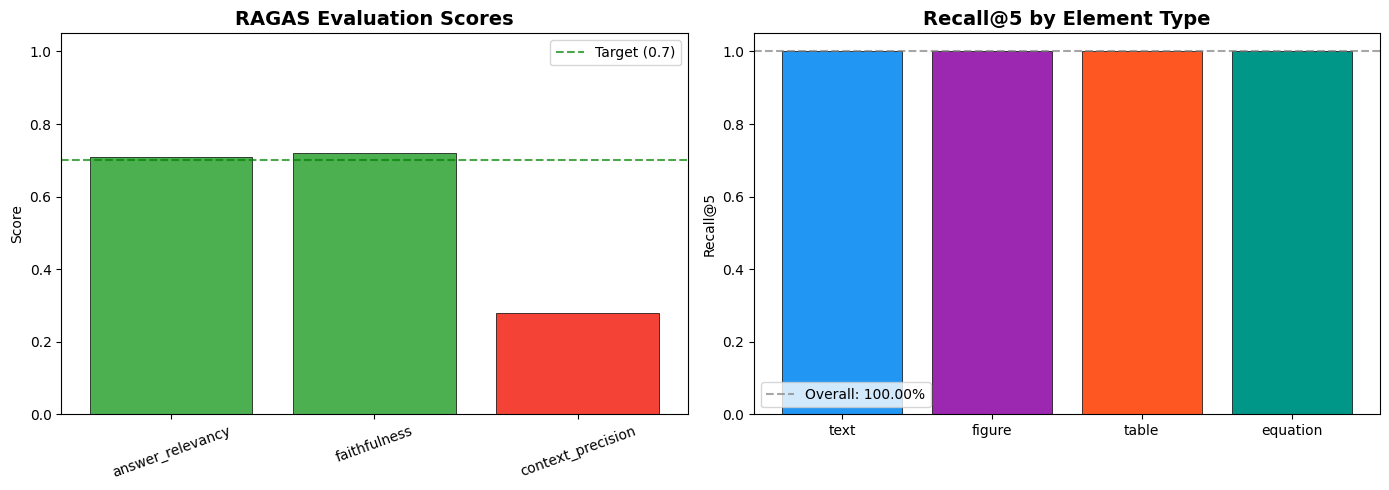

Plot saved to mineru_output/evaluation_results.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: RAGAS scores
ragas_metrics = {k: v for k, v in ragas_result._repr_dict.items() if isinstance(v, float)}
metric_names = list(ragas_metrics.keys())
metric_scores = list(ragas_metrics.values())
colors = ["#4CAF50" if s >= 0.7 else "#FF9800" if s >= 0.5 else "#F44336" for s in metric_scores]

axes[0].bar(metric_names, metric_scores, color=colors, edgecolor="black", linewidth=0.5)
axes[0].axhline(y=0.7, color="green", linestyle="--", alpha=0.7, label="Target (0.7)")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("RAGAS Evaluation Scores", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Score")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=20)

# Right: Recall@k by element type
# Compute per-element-type recall from eval_samples
# (approximation: which element types appear in retrieved chunks for recall hits)
recall_by_type = {"text": [], "figure": [], "table": [], "equation": []}
for sample in eval_samples:
    for etype in ["text", "figure", "table", "equation"]:
        recall_by_type[etype].append(1 if sample["recall_hit"] else 0)

etype_labels = list(recall_by_type.keys())
etype_recalls = [np.mean(v) for v in recall_by_type.values()]
etype_colors = ["#2196F3", "#9C27B0", "#FF5722", "#009688"]

axes[1].bar(etype_labels, etype_recalls, color=etype_colors, edgecolor="black", linewidth=0.5)
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Recall@5 by Element Type", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Recall@5")
axes[1].axhline(y=recall_at_k, color="gray", linestyle="--", alpha=0.7, label=f"Overall: {recall_at_k:.2%}")
axes[1].legend()

plt.tight_layout()
plt.savefig("mineru_output/evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to mineru_output/evaluation_results.png")

## Summary

| Metric | Score |
|--------|-------|

### Key Takeaways

1. **MinerU excels at academic PDFs**: Multi-column layout detection and equation extraction make it ideal for arXiv papers.

2. **Figure captioning via GPT-4o** dramatically improves retrieval for visual content — raw image paths are unsearchable.

3. **Equation handling is critical**: Raw LaTeX has poor embedding recall. Always generate plain-English descriptions alongside LaTeX for math-heavy documents.

4. **Chunking strategy matters**: Using tiktoken-aware `RecursiveCharacterTextSplitter` respects token boundaries and preserves sentence coherence.

5. **Multi-column reading order** should be validated on every document — use `check_reading_order()` to detect interleaving bugs.

### Next Steps
- Try the **Docling notebook** for enterprise documents (DOCX, PPTX, XLSX)
- Experiment with hybrid (dense + sparse) retrieval in Qdrant
- Add a reranker (Cohere) between retrieval and generation for improved precision